<div align="center">
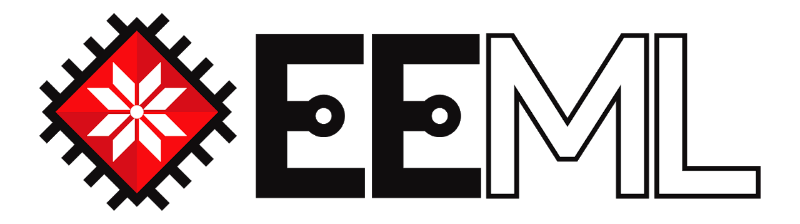

<h3>EEML 2026 — Efficiency Tutorial</h3>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eemlcommunity/PracticalSessions2026/blob/main/4_efficiency/tutorial.ipynb)


# Model Quantization

In this tutorial, you're going to implement post-training quantization approaches for _Large Language Models_, ranging from naive ones to the State of The Art. The main goal is to implement [GPTQ](https://arxiv.org/abs/2210.17323).

<font color='red'>Important note:</font>
This version runs on **CPU, Apple-Silicon GPU (MPS), or CUDA** — choose with the `DEVICE` selector near the top. Because CPU inference is slow, the evaluation dataset size is exposed as variables (`SEQLEN`, `N_CALIB_SAMPLES`, `N_TEST_SAMPLES`) so you can trade runtime against sharpness — reduce them for a quick smoke test, increase them (up to the full test set) for a more meaningful perplexity.

This version uses the gated **base** model [`swiss-ai/Apertus-v1.1-0.5B`](https://huggingface.co/swiss-ai/Apertus-v1.1-0.5B) (the base model, not the `-Instruct` variant, because we evaluate raw-text perplexity and use plain completion prompts rather than a chat template).

## Tutorial Plan


1. **Setup** (~5 min) —  dependencies and imports.
2. **Low-precision formats** (~10 min) — decode INT4 and FP4 bit patterns and visualize the values.
3. **Row-wise quantization** (~20 min) — implement the quantization to uint with scale/zero mapping.
4. **4 bit RTN quantization of Apertus-0.5B** (~15 min) — quantize every linear layer to 4 bits; watch the model break.
5. **Evaluation on WikiText-2** (~10 min) — download the data; run the model layer-by-layer to measure PPL.
6. **Control: 8-bit RTN** (~5 min) — repeat RTN at 8 bits to show the failure is specific to 4 bits.
7. **GPTQ** (~30 min) — implement and run GPTQ.
8. **QAT via distillation** (~20 min + ~15 min compute) — fine-tune the GPTQ model with a straight-through estimator and KL distillation from the FP32 teacher.


# Installing the Dependencies

In [ ]:
%pip install torch transformers==4.57.1 sentencepiece==0.2.1 datasets==4.0.0 accelerate==1.11.0 numpy matplotlib

### Imports

In [ ]:
import os
import math
import random
from tqdm.auto import tqdm, trange
from typing import Mapping
import matplotlib.pyplot as plt

import torch
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, PreTrainedModel
from datasets import load_dataset

from itertools import product

import matplotlib.pyplot as plt
import numpy as np

def download_file(url: str, path: str):
    """Download a file over HTTPS (portable replacement for the shell `wget`)."""
    import urllib.request
    with urllib.request.urlopen(url, timeout=60) as response, open(path, "wb") as out:
        out.write(response.read())

### Compute device

In [ ]:
# DEVICE: "cpu", "mps" (Apple Silicon), "cuda", or "auto".
# "auto" prefers cuda > mps > cpu by availability.
DEVICE = "auto"

if DEVICE == "auto":
    DEVICE = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available()
              else "cpu")

if DEVICE == "mps":
    os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # route any unimplemented op to CPU
DTYPE = torch.float32

print(f"DEVICE = {DEVICE}  |  DTYPE = {DTYPE}")

In [ ]:
MODEL_NAME = "swiss-ai/Apertus-v1.1-0.5B"

def get_model_and_tokenizer():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, dtype=DTYPE,
    ).to(DEVICE)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    model.config.pad_token_id = model.config.eos_token_id
    tokenizer.pad_token_id = tokenizer.eos_token_id

    return model, tokenizer

# Low Precision Formats

## Integer formats
An (n)-bit integer contains (n) binary digits:
$
i_0 i_1 \dots i_{n-1}.
$


For an unsigned integer, all bits contribute to the magnitude:

$ v = \sum_{j=0}^{n-1} i_j 2^{n-j-1}$.

The representable range is $ 0 \dots 2^n - 1$.

Signed integers are represented using the first bit as an offset:
$v = -i_0 2^{n-1} + \sum_{j=1}^{n-1} i_j 2^{n-j-1}$

The representable range is $-2^{n-1} \dots 2^{n-1}-1$.

## Floating Point formats

A binary floating-point number is divided into three fields:

one sign bit,
(k) exponent bits,
(m) mantissa bits.

The exponent controls the numerical range, while the fraction bits control precision.

For the normal range ($e \neq 0$) the represented value is

 $(-1)^s \cdot 1.m_0 m_1 \dots m_{n-1} \cdot 2^{e_0 \dots e_{k-1} - B}$

where:

$s$ is the sign bit,
$m_i$ are mantissa bits,
$e_i$ are exponent bits,
$B$ is the exponent bias.

Some floating point formats:

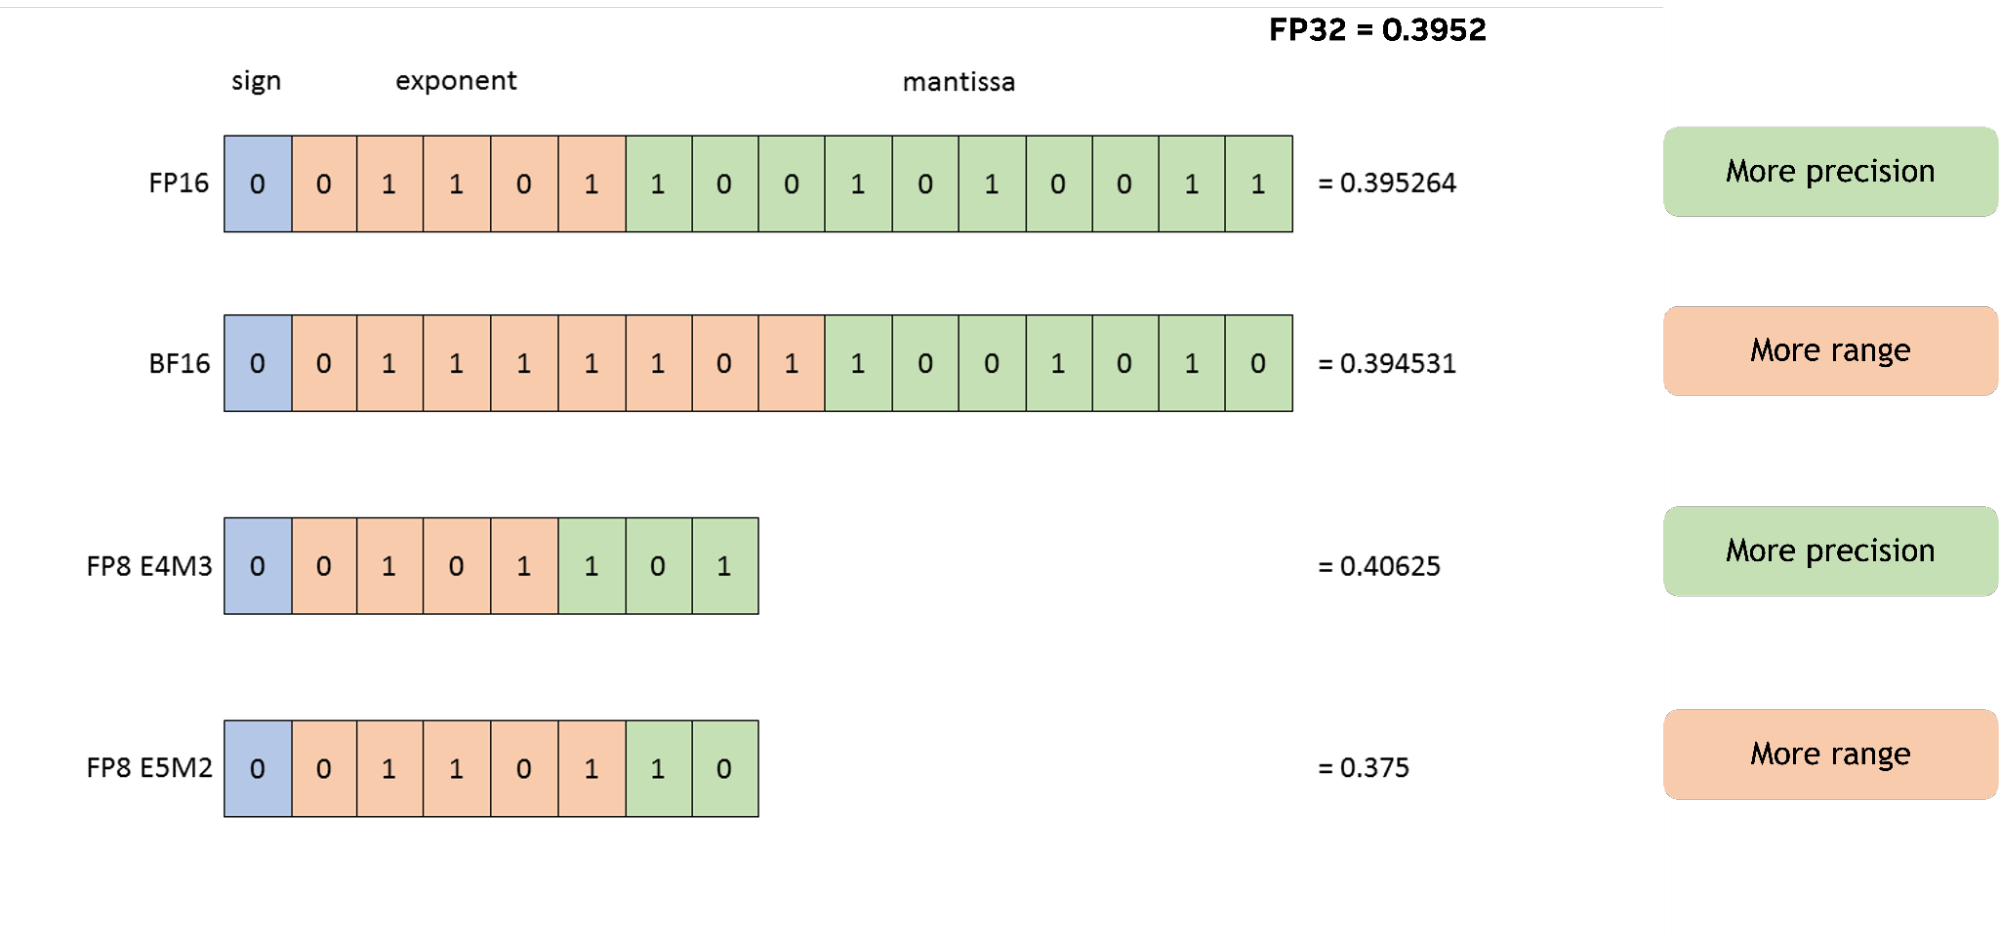

source: https://developer.nvidia.com/blog/floating-point-8-an-introduction-to-efficient-lower-precision-ai-training/

### Task 0.
INT4 and FP4 are compact 4-bit numerical formats used to reduce memory usage and increase computational throughput. Visualize the number range of signed INT4 and FP4 (S1 E2 M1).

In [ ]:
BITS = 4

def int4_values(bit_arrays):
    """Convert 4-bit arrays to represented values."""
    values = []
    for bits in bit_arrays:

        # YOUR CODE HERE>>>>>>>>>
        # signed_value = 
        # <<<<<<<<<<<<<<<<<<<<<<<

        values.append(signed_value)
    return np.array(values)

def fp4_values(bit_arrays):
    """
    Convert FP4 E2M1 bit arrays to represented values.
    Bit layout: [sign, exponent_1, exponent_0, mantissa]
    """
    values = []
    exponent_bias = 1

    for bits in bit_arrays:

        sign_bit = bits[0]
        sign = -1 if sign_bit else 1
        exponent = bits[1] * 2 + bits[2]
        mantissa = bits[3]

        if exponent == 0:
            # Subnormal range:
            # (-1)^sign × 0.m × 2^(1-bias)
            value = sign * (mantissa / 2) * 2 ** (1 - exponent_bias)

        else:
            # Normal range:
            # (-1)^sign × 1.m × 2^(exponent-bias)

            # YOUR CODE HERE>>>>>>>>>
            #value = 
            # <<<<<<<<<<<<<<<<<<<<<<<

        values.append(value)

    return np.array(values)

In [ ]:
def visualise_4bit_formats():
    bit_values = [list(bits) for bits in product([0, 1], repeat=BITS)]

    integer_values = int4_values(bit_values)
    floating_values = fp4_values(bit_values)
    fig, axes = plt.subplots(2, 1, figsize=(11, 3))

    formats = [("signed INT4", integer_values),
        ("FP4 E2M1", floating_values)]

    for axis, (title, values) in zip(axes, formats):
        axis.grid(axis="both", alpha=1, which='both', zorder=-1)
        axis.scatter(values, np.zeros(len(values)), zorder=2)
        axis.axhline(y=0, color="black", linewidth=1, zorder=0)

        for bits, value in zip(bit_values, values):
            if bits == [1,0,0,0] and title == "FP4 E2M1": continue
            bit_string = "".join(map(str, bits))

            axis.annotate(bit_string,
                (value, 0),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8)

        axis.set_title(title)
        axis.set_xlim(-9, 9)
        axis.set_yticks([])
        axis.set_xlabel("Represented value")

    plt.tight_layout()
    plt.show()

visualise_4bit_formats()

# Quantizing Matrices Row-Wise

A numerical format defines the available values; quantization procedure determines how high-precision model weights are mapped onto those values.

### Basic Quantization

**Mapping the values to the allowed range**

Quantization is the process of mapping input values from a large set to output values in a smaller set. For instance, if we consider 4-bit
quantization, our values are represented by $4$ bits, meaning we can represent values between 0 and $2^4-1=15$.

 * To produce the quantized representation, we need to be able to map the matrix values to and from this range.
 * For the reason below, we will perform this mapping independently for each matrix row.
 * We will parametrize the mapping like this: $out = \frac{in}{scale} + zero$, where $scale$ and $zero$ are row-wise constants.
 * For a matrix of size `(m, k)` ($m$ rows, $k$ columns) we will aggregate those parameters into two vectors `scale` and `zero` of size `(m, 1)`.

Model parameters are usually stored as matrices. For a linear layer $
\mathbf{y} = W\mathbf{x} + \mathbf{b}$,
where $W \in \mathbb{R}^{d_{\text{out}} \times d_{\text{in}}}$. In PyTorch, an nn.Linear layer stores its weights as a tensor with shape: (out_features, in_features).

Different output values can have very different weight ranges. If the entire matrix uses one global quantization scale, the row with the largest range determines the spacing between quantization levels.

Notice that each row $W_{i,:}$ contains all the weights used to produce one output value. Therefore we will implement **row-wise** or **per-channel quantization** which assigns a separate scale and zero-point to every matrix row.

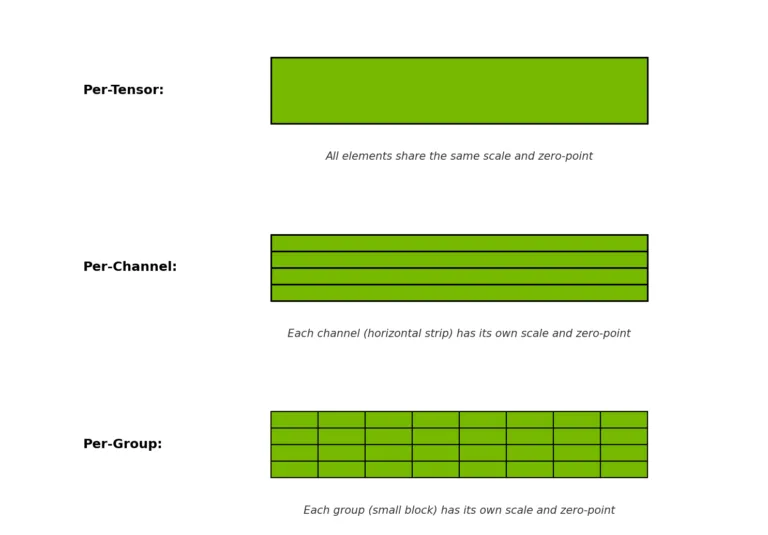

source: https://developer.nvidia.com/blog/?p=108929

**Task:** Complete the function below to perform this mapping:

In [ ]:
def get_scale_and_zero(x: Tensor, max_abs: float) -> tuple[Tensor, Tensor]:
    """ Given a tensor x of shape (m, k) and max_abs > 0 produce tensors scale and zero of shape (m, 1)
        such that 0 <= x / scale + zero <= max_abs"""
    # YOUR CODE HERE>>>>>>>>>

    # scale = 
    # zero = 

    # <<<<<<<<<<<<<<<<<<<<<<<
    return scale, zero


Check the values of your scale and zero:

In [ ]:
x = torch.tensor([[-1.20, -0.7, -0.18, 0.37, 1.04, 1.80]])

print("Your scale and zero:", get_scale_and_zero(x, 2**4 - 1))

In [ ]:
# Testing your code

x = torch.arange(512 * 1024).reshape(512, 1024).float()
scale, zero = get_scale_and_zero(x, 15)
assert scale.shape == (512, 1), "scale is wrong shape"
assert zero.shape == (512, 1), "zero is wrong shape"
assert torch.all(scale * 15 <= 1023.1), "Scale can't be that large. The resulting interval is too wide"
assert torch.all(scale * 15 >= 1022.9), "Scale shouldn't be that small. The resulting interval is too narrow"
assert torch.all(-0.001 <  x / scale + zero) and torch.all(x / scale + zero < 15 + 0.001)

x = torch.zeros(128, 128)
scale, zero = get_scale_and_zero(x, 15)
assert torch.all(scale == 1) and torch.all(scale * 15 >= 0.99), "If all the values in a row are identical, let us set scale to 1"
print("All tests passed!")

**Quantization**

Having mapped the values into the allowed range, we can simply round them to obtain the quantized matrix. Complete the functions below to perform row-wise quantization. Note that:
 * You should `torch.clamp(...)` the quantized values to ensure that they are in the allowed range.
 * Some functions return the quantized matrix, as well as the quantization constants, because we'll need them to dequantize the matrix. Use `get_scale_and_zero` to obtain the them.
 * Note that we cast the quantized tensor to `uint8`, but the values themselves must be in the possibly narrower range, as determined by the number of bits. Obviously, we require the latter to be less or equal than 8.

**Task:** Complete the function below to perform quantization:

In [ ]:
def quantize(x: Tensor, scale: Tensor, zero: Tensor, bits: int) -> Tensor:
    """Quantizes a tensor
    Args:
        x (Tensor): tensor to quantize
        scale (Tensor): values interval mapping scale
        zero (Tensor): values interval mapping zero
        bits (int): number of bits to quantize to

    Returns:
        Tensor: quantized tensor in uint8
    """
    # YOUR CODE HERE>>>>>>>>>
    # quantized_x = 
    # <<<<<<<<<<<<<<<<<<<<<<<
    return quantized_x.to(torch.uint8)


def dequantize(quantized_x: Tensor, scale: Tensor, zero: Tensor) -> Tensor:
    """Dequantize a tensor
    Args:
        quantized_x (Tensor): quantized tensor in uint8
        scale (Tensor): values interval mapping scale
        zero (Tensor): values interval mapping zero

    Returns:
        Tensor: dequantized tensor
    """
    # YOUR CODE HERE>>>>>>>>>
    # return 
    # <<<<<<<<<<<<<<<<<<<<<<<


def measure_and_quantize(x: Tensor, bits: int) -> tuple[Tensor, Tensor, Tensor]:
    """Determine the values interval mapping parameters and quantize a tensor
    Args:
        x (Tensor): tensor to quantize
        bits (int): number of bits to quantize to

    Returns:
        tuple[Tensor, Tensor, Tensor]: quantized tensor, scale, zero
    """
    # YOUR CODE HERE>>>>>>>>>

    # <<<<<<<<<<<<<<<<<<<<<<<
    return x_quantized, scale, zero


Check your quantized and de-quantized vector:

In [ ]:
x = torch.tensor([[-1.20, -0.7, -0.18, 0.37, 1.04, 1.80]])

scale, zero = get_scale_and_zero(x, 2**4 - 1)
quantized_x = quantize(x, scale, zero, 4)
dequantized_x = dequantize(quantized_x, scale, zero)

print("Original:", x, "\n Quantized:", quantized_x,
      "\n Dequantized:", dequantized_x)

In [ ]:
# Testing your code

x = torch.arange(512 * 1024).reshape(512, 1024).float()
scale, zero = get_scale_and_zero(x, 15)
quantized_x, scale, zero = measure_and_quantize(x, 4)

assert quantized_x.shape == x.shape, "Shape of quantized_x is incorrect"
assert scale.shape == (512, 1), "Shape of scale is incorrect"
assert zero.shape == (512, 1), "Shape of zero is incorrect"
assert torch.all(quantized_x >= 0) and torch.all(quantized_x <= 15) and torch.any(quantized_x == 15), "wrong quantized_x values range"
assert torch.allclose(x, dequantize(quantized_x, scale, zero), atol=50), "Dequantized values are too far from the original values"
print("All tests passed!")

**Using the quantized matrix**

To use the matrix in matrix multiplication operations, we'll have to decode the quantized values back into their original form. In real inference scenarios, this would be done in-flight with a custom quantized GEMM CUDA kernel. Here, however, we materialize the dequantized weight for simlicity.

In [ ]:
class QuantizedLinear(nn.Module):
    def __init__(self, quantized_weight, scale, zero, bias):
        super().__init__()
        self.quantized_weight = nn.Parameter(quantized_weight, requires_grad=False)
        self.scale = nn.Parameter(scale, requires_grad=False)
        self.zero = nn.Parameter(zero, requires_grad=False)
        self.bias = nn.Parameter(bias.data.clone().detach()) if bias is not None else None

    def forward(self, input):
        return F.linear(input, dequantize(self.quantized_weight, self.scale, self.zero), self.bias)


This class will be used as a replacement for `nn.Linear`. It holds the quantized weight and only dequantizes it during it's forward passes.

# LLM Quantization

In this section you will implement quantization of linear layers for a relatively small 0.5B model to 4 and 8 bits and evaluate performance of these quantized models.

### RTN Quantization for Apertus

**Auxiliary functions:**

In [ ]:
def find_linear_layers(module: nn.Module, name='') -> dict[str, nn.Module]:
    """
    Returns a dict of all nn.Linear submodules in a module with paths as keys
    """
    if type(module) == nn.Linear:
        return {name: module}
    res = {}
    for name1, child in module.named_children():
        res.update(find_linear_layers(
            child, name=name + '.' + name1 if name != '' else name1
        ))
    return res


def replace_submodule(module, submodule_path, new_submodule):
    """
    Replaces a submodule specified by a path with a new submodule
    """
    submodule_names = submodule_path.split(".")
    for submodule in submodule_names[:-1]:
        module = getattr(module, submodule)
    setattr(module, submodule_names[-1], new_submodule)

**Load-Quantize cycle**

First, take a look at the function below. It uses the functions above to load the layers one by one and iterate over their `Linear` submodules, replacing them with `QuantizedLinear`. Everything runs on CPU here: the model is loaded in `float32` and we process the layers one at a time to keep the memory footprint reasonable.

**Task:** implement RTN quantization for *Apertus*

In [ ]:
@torch.no_grad()
def quantize_rtn(model: PreTrainedModel, bits: int):
    """Iterates Apertus layers one by one and quantizes them with RTN
    Args:
        model (PreTrainedModel): model to quabtuze
        bits (int): number of bits to quantize to
    """
    # Load and quantize all the layers
    layers = model.model.layers
    for i in trange(len(layers)):
        # Replace all linear submodules with QuantizedLinear
        # Use:
        #   - find_linear_layers
        #   - replace_submodule

        layer = layers[i]

        linear_submodules = find_linear_layers(layer)
        for name, linear in linear_submodules.items():
        # YOUR CODE HERE>>>>>>>>>

            # new_submodule = QuantizedLinear(...)

        # <<<<<<<<<<<<<<<<<<<<<<<
        layers[i] = layer

### Testing the Quantized Model

Now we have everything we need to quantize the _Apertus-0.5B_ model to 4 bits. Let us do that.

In [ ]:
SEED = 0
BITS = 4

In [ ]:
model, tokenizer = get_model_and_tokenizer()
quantize_rtn(model, BITS)

In [ ]:
linear_names = [name for name, module in model.named_modules() if isinstance(module, torch.nn.Linear)]
assert linear_names == ['lm_head'], f"Only lm_head shall not be quantized, got {linear_names}"

In [ ]:
# This is a base language model, so we prompt it with text to continue
# (no chat template). A healthy quantized model completes these coherently.
PROMPTS = [
    "The capital of France is",
    "The Pacific Ocean is",
    "Isaac Newton was a",
    "The theory of evolution by natural selection was proposed by",
]

def generate_samples(model, tokenizer, prompts, max_new_tokens=40):
    samples = []
    for prompt in prompts:
        enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, repetition_penalty=1.3, pad_token_id=tokenizer.eos_token_id)[0]
        samples.append(tokenizer.decode(out, skip_special_tokens=True))
    return samples

In [ ]:
print("=== 4-bit RTN model ===\n")
print(*generate_samples(model, tokenizer, PROMPTS), sep="\n\n")

In [ ]:
model = model.to(DEVICE)

### Evaluating the model

Before we start quantizing the model itself, let us create a way to evaluate it's performance.


**Downloading the data**

As a metric of the models' performance, we'll use its PPL on the [wikitext2](https://paperswithcode.com/dataset/wikitext-2) dataset. Let us download and tokenize it. We'll need two subsets:
 * A **test set** (`N_TEST_SAMPLES` sequences of length `SEQLEN`) to evaluate the models.
 * A **train subset** (`N_CALIB_SAMPLES` sequences) that we'll use later as calibration data for GPTQ.

These sizes trade CPU runtime against perplexity sharpness: reduce them (e.g. `SEQLEN=512`, `N_TEST_SAMPLES=8`) for a quick smoke test, or set `N_TEST_SAMPLES=None` to use the full test set.

In [ ]:
def get_wikitext2(seed, seqlen, nsamples=64, max_test_samples=None):
    traindata = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    testdata = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_input_ids = tokenizer("\n\n".join(traindata['text']), return_tensors='pt').input_ids
    random.seed(seed)
    train_batch = []
    for _ in range(nsamples):
        i = random.randint(0, train_input_ids.shape[1] - seqlen - 1)
        j = i + seqlen
        inp = train_input_ids[:, i:j]
        train_batch.append(inp[0])

    test_input_ids = tokenizer("\n\n".join(testdata['text']), return_tensors='pt').input_ids
    test_input_ids = test_input_ids[:, :(test_input_ids.shape[1] // seqlen) * seqlen]
    test_input_ids = test_input_ids.reshape(test_input_ids.shape[1] // seqlen, seqlen)

    # Limit the number of test sequences to keep CPU evaluation tractable
    if max_test_samples is not None:
        test_input_ids = test_input_ids[:max_test_samples]

    return torch.stack(train_batch), test_input_ids

In [ ]:
SEED = 0

# --- Evaluation scope (trade off CPU runtime vs. PPL sharpness; reduce for a quick smoke test) ---
SEQLEN = 2048           # sequence length for PPL eval and GPTQ calibration
N_CALIB_SAMPLES = 16    # number of calibration sequences for GPTQ
N_TEST_SAMPLES = 16     # number of wikitext2 test sequences for PPL; set to None for the full test set

train_batch, test_input_ids = get_wikitext2(
    SEED, SEQLEN, nsamples=N_CALIB_SAMPLES, max_test_samples=N_TEST_SAMPLES,
)
print(f"train_batch: {tuple(train_batch.shape)}, test_input_ids: {tuple(test_input_ids.shape)}")

**Processing the model layer by layer**

We'll evaluate the model on fairly long sequences. To keep peak memory low, we process the model one layer at a time: we run the inputs through a layer, store its outputs, and move on to the next layer. (On the original GPU setup this layer streaming was used to fit the model in limited VRAM; on CPU it simply keeps the working set small.)

**Obtaining the first layer inputs**

To start iterating over the layers, we'll first have to obtain the first layer inputs. We use the function below to do it.

In [ ]:
import torch
from torch import nn, Tensor


class Catcher(nn.Module):
    def __init__(self):
        super().__init__()

        # We know that Apertus layers take a Tensor of hidden states,
        # and some kwargs of which `position_embeddings` is required.
        # `position_embeddings` are also the same for the entire dataset,
        # so we only have to register the last ones
        self.hidden_states = []
        self.position_embeddings = None


    def forward(self, hidden_states, **kwargs):
        assert hidden_states.shape[0] == 1 # only one element from dataset
        self.hidden_states.append(hidden_states[0])
        self.position_embeddings = kwargs['position_embeddings']
        raise ValueError

    def get_the_catch(self):
        return torch.stack(self.hidden_states), self.position_embeddings


def get_first_layer_inputs(model: nn.Module, model_inputs: Tensor):
    catcher = Catcher()
    original_layers = model.model.layers

    try:
        model.model.layers = nn.ModuleList((catcher,))
        for sample in model_inputs:
            try:
                model(sample.unsqueeze(0).to(DEVICE))
            except ValueError:
                pass
    finally:
        model.model.layers = original_layers

    return catcher.get_the_catch()

**Forward passing layer-by-layer**

In [ ]:
def forward_pass_layer(layer: nn.Module, inps: torch.Tensor, outs: torch.Tensor, position_embeddings: Tensor):
    """Forward pass inps through the layer ONE INP AT A TIME saving the outputs into the corresponding elements of outs"""
    for j in range(inps.shape[0]):
        outs[j] = layer(inps[j].unsqueeze(0), position_embeddings=position_embeddings)[0]


def get_batch_nll(model: nn.Module, batch: Tensor):
    # Collect the first layer inputs
    inps, position_embeddings = get_first_layer_inputs(model, batch)

    # Create a buffer for layer outputs
    outs = torch.zeros_like(inps)

    # Forward pass through the layers one by one
    layers = model.model.layers
    for i in trange(len(layers), leave=False):
        layer = layers[i]

        forward_pass_layer(layer, inps, outs, position_embeddings) # Forward pass a layer
        inps, outs = outs, inps # Prepare the inputs and the output buffer for the next layer. Reuse the existing buffers

    # Calculate NLL
    nll = 0
    for i in range(inps.shape[0]):
        lm_logits = model.lm_head(model.model.norm(inps[i].unsqueeze(0)))
        labels = batch[i]
        # Calculate the language modeling Negative Log Likelyhood
        shift_logits = lm_logits[:, :-1, :]
        shift_labels = labels[1:]
        loss = torch.nn.functional.cross_entropy(
            shift_logits.float().view(-1, shift_logits.size(-1)),
            shift_labels.view(-1).to(DEVICE),
            reduction="sum",
        )
        nll += float(loss)
    return nll


@torch.no_grad()
def eval_ppl(model, test_input_ids):
    print('Evaluating ...')

    total_nll = 0
    n_chunks = min(4, test_input_ids.shape[0])
    for batch in tqdm(torch.tensor_split(test_input_ids, n_chunks)):
        total_nll += get_batch_nll(model, batch)

    # Calculate PPL
    ppl = math.exp(total_nll / test_input_ids[:,:-1].numel())
    print(f"PPL: {ppl}")
    return ppl

**Calculating PPL**

We've already loaded and quantized the model. All that's left is to evaluate it.

In [ ]:
rtn_ppl = eval_ppl(model, test_input_ids)

In [ ]:
# Testing your code

# 4-bit RTN is catastrophic on this model -- we contrast it with 8-bit RTN below and
# with GPTQ further down. Here we only sanity-check that the eval produced a finite value.
assert math.isfinite(rtn_ppl) and rtn_ppl > 0
print(f"RTN 4-bit PPL = {rtn_ppl:.3f}")
print("All tests passed!")

In [ ]:
del model

### 8-bit RTN — the failure is specific to 4 bits

The 4-bit RTN model above is essentially broken. To show that this is a property of the
**4-bit** grid (and not of the model or our evaluation), let's repeat RTN at **8 bits**.
The 8-bit model should generate coherent text and reach a perplexity close to the
full-precision baseline.

In [ ]:
# Quantize a fresh copy of the model to 8 bits with RTN
model, tokenizer = get_model_and_tokenizer()
ppl_baseline = eval_ppl(model, test_input_ids)

print("=== 8-bit RTN model ===\n")
quantize_rtn(model, 8)
print(*generate_samples(model, tokenizer, PROMPTS), sep="\n\n")

rtn_ppl_8bit = eval_ppl(model, test_input_ids)
del model

In [ ]:
# Testing your code
print(f"RTN 4-bit PPL : {rtn_ppl:9.2f}")
print(f"RTN 8-bit PPL : {rtn_ppl_8bit:9.2f}")
print(f"Unquantzed PPL: {ppl_baseline:9.2f}")
assert math.isfinite(rtn_ppl_8bit) and rtn_ppl_8bit > 0
assert rtn_ppl_8bit < rtn_ppl, "8-bit RTN should be far better than 4-bit RTN"
assert rtn_ppl_8bit < ppl_baseline + 1, "8-bit RTN should land close to the full-precision baseline"
print("All tests passed!")

### GPTQ

GPTQ ([Frantar et al., 2022](https://arxiv.org/abs/2210.17323)) is a state-of-the-art post-training quantization algorithm. It quantizes a layer's weight **one column at a time** and is **input-aware**: instead of merely rounding, it chooses quantized weights that best preserve the layer's *output* on representative inputs.

**Objective.** For a weight $W \in \mathbb{R}^{\text{OUT}\times\text{IN}}$ and layer inputs $X \in \mathbb{R}^{\ast\times\text{IN}}$, GPTQ minimizes the output error

$$
\widehat{W} \;=\; \arg\min_{\widehat{W}}\; \bigl\| X W^\top - X\widehat{W}^\top \bigr\|_2^2 ,
$$

with $\widehat{W}$ restricted to the (row-wise) quantization grid; the squared norm sums over all rows of $X$.

The objective is **separable over the rows of $W$** (each output channel is independent) — which is exactly why we quantize row-wise. So take a single row $w \in \mathbb{R}^{\text{IN}}$: its objective is quadratic in $w$, with **Hessian**

$$
H \;=\; 2\,X^\top X \;\in\; \mathbb{R}^{\text{IN}\times\text{IN}},
$$

the *same* for every row (it depends only on $X$). With $\text{IN}$ unknowns this is too large to solve exactly, so GPTQ solves it greedily, one weight at a time.

**Greedy update.** Let $q(\cdot)$ round a value onto the quantization grid (the `quantize`$\to$`dequantize` round-trip). Until the row is fully quantized:

1. choose the next index $i$;
2. quantize it: $\widehat{w}_i = q(w_i)$;
3. **compensate** the remaining (not-yet-quantized) weights for the rounding error, using the inverse Hessian:
$$
w_{i:} \;\leftarrow\; w_{i:} \;-\; \frac{w_i - q(w_i)}{[H^{-1}]_{ii}}\,[H^{-1}]_{i,\,i:} ;
$$
4. remove $i$ from the remaining set.

Visiting indices in order of **decreasing $H_{ii}$** (most-confident weights first) works best.

A few ideas make this practical — and they are exactly what the code below implements:

1. **Fix the order up front.** Permute the columns of $W$ (and of $H$) into decreasing-$H_{ii}$ order, then simply sweep $i = 1, 2, \dots$ left to right.
2. **Vectorize over rows.** The same order serves every row, so update all rows together. With $W_{:,i}$ the $i$-th column, the step is an **outer product** (a column times a row):
$$
W_{:,\,i:} \;\leftarrow\; W_{:,\,i:} \;-\; \frac{W_{:,i} - q(W_{:,i})}{[H^{-1}]_{ii}}\,[H^{-1}]_{i,\,i:} . \qquad \textbf{(you implement this)}
$$
3. **Precompute $H^{-1}$ once, via Cholesky.** Each step needs only one row of $H^{-1}$, and the upper-triangular **Cholesky factor** of $H^{-1}$ supplies those rows in order, more stably. *From here on $H^{-1}$ denotes this precomputed Cholesky factor* — it is what the code passes around as `hessian_inverse`.
4. **Batch the updates into blocks.** Applying the rank-1 update to *all* trailing columns after every single column is wasteful. Within a block we update only the columns *inside* the block right away, while accumulating each column's **scaled error**
$$
E_{:,i} \;=\; \frac{W_{:,i} - q(W_{:,i})}{[H^{-1}]_{ii}} ,
$$
then apply the block's combined correction to the columns *after* the block in one matrix product (below).

**GPTQ within a block.**

Implement one block of the sweep: go over the block's columns left to right, quantizing each with $q(\cdot)$ and applying the outer-product compensation (idea 2) to the remaining columns **inside the block**. Return the quantized columns and the matrix of scaled errors $E$ (idea 4) — the full algorithm uses $E$ to correct the columns *after* the block.

**Task:** Implement the GPTQ block:

In [ ]:
@torch.no_grad()
def gptq_block(block_weight: Tensor, block_hessian_inverse: Tensor, scale: Tensor, zero: Tensor, bits: int) -> tuple[Tensor, Tensor]:
    """Perform GPTQ within block
    Args:
        block_weight (Tensor): weight to quantize of shape (OUT, BLOCK_SIZE)
        block_hessian_inverse (Tensor): Cholesky inverse Hessian. Upper triangular of shape (BLOCK_SIZE, BLOCK_SIZE)
        scale (Tensor): row-wise quantization constats of shape (OUT, 1)
        zero (Tensor): row-wise quantization constats of shape (OUT, 1)
        bits (int): number of bits to quantize() to

    Returns:
        tuple[Tensor, Tensor]: quantized weight and scaled quantization error
    """
    block_weight = block_weight.clone()
    quantized_block_weight = torch.zeros(block_weight.shape, dtype=torch.uint8, device=block_weight.device)
    scaled_block_error = torch.zeros_like(block_weight)

    # Interate over the block's columns
    for i in range(block_weight.shape[1]):
        # Get the column and the corresponding inverse Hessian
        column_weight = block_weight[:, [i]]
        hessian_slice = block_hessian_inverse[[i], i:]
        # YOUR CODE HERE>>>>>>>>>

        # <<<<<<<<<<<<<<<<<<<<<<<

    return quantized_block_weight, scaled_block_error


In [ ]:
# Testing your code

# Reference tensors are vendored in the repo; download them only if missing.
REF_BASE = "https://raw.githubusercontent.com/eemlcommunity/PracticalSessions2026/main/4_efficiency/"
for _fn in ("gptq_block_weight_reference.pt", "gptq_block_error_reference.pt"):
    if not os.path.exists(_fn):
        download_file(REF_BASE + _fn, _fn)

generator = torch.Generator()
generator.manual_seed(0)

weight = torch.rand((128, 128), generator=generator)
scale, zero = get_scale_and_zero(weight, 15)

block_weight = weight[:,:16]

block_hessian_inverse = (torch.triu(torch.rand((16, 16), generator=generator), diagonal=1) + torch.diag(torch.rand(16, generator=generator) + 1))
quantized_block_weight, scaled_block_error = gptq_block(block_weight, block_hessian_inverse, scale, zero, 4)

# The bundled reference tensors were generated on GPU; allow tiny numerical differences on CPU.
weight_ref = torch.load("gptq_block_weight_reference.pt", map_location="cpu")
error_ref = torch.load("gptq_block_error_reference.pt", map_location="cpu")
weight_match = (quantized_block_weight.int() == weight_ref.int()).float().mean().item()
print(f"quantized weight exact-match vs reference: {weight_match:.4f}")
assert weight_match > 0.99
assert torch.allclose(scaled_block_error, error_ref, rtol=1e-3, atol=1e-4)

print("All tests passed!")

**Now the full algorithm:**
 * Compute the row-wise quantization grid (`scale`, `zero`).
 * Permute the columns by **decreasing $H_{ii}$** (idea 1), permuting $H$ to match.
 * Precompute the Cholesky factor $H^{-1}$ (idea 3).
 * Sweep the columns block by block; for each block:
   * quantize it with the block function above (which also returns the scaled errors $E$);
   * correct every column *after* the block in one matrix product (idea 4):
$$
W_{:,\,\text{end}:} \;\leftarrow\; W_{:,\,\text{end}:} \;-\; E_{:,\,\text{start}:\text{end}}\;[H^{-1}]_{\text{start}:\text{end},\;\text{end}:} .
$$
 * Undo the column permutation on the quantized weight.

**Task:** Implement the full algorithm:

In [ ]:
def prepare_inverse_hessian(hessian: Tensor, percdamp: float) -> Tensor:
    """Precomputes inverse Hessian
    Args:
        hessian (Tensor): problem hessian
        percdamp (float): diagonal damping constant for numerical stability
    Returns:
        Tensor: precomputed inverse Hessian
    """
    hessian = hessian.clone().detach()
    damp = percdamp * torch.mean(torch.diag(hessian))
    diag = torch.arange(hessian.shape[0], device=hessian.device)
    hessian[diag, diag] += damp
    hessian = torch.linalg.cholesky(hessian)
    hessian = torch.cholesky_inverse(hessian)
    hessian = torch.linalg.cholesky(hessian, upper=True)
    return hessian


@torch.no_grad()
def gptq(weight: torch.Tensor, bits: int, hessian: torch.Tensor, blocksize:int=128, percdamp:float=.01) -> tuple[Tensor, Tensor, Tensor]:
    """Quantizes weight with GPTQ
    Args:
        weight (torch.Tensor): weight to quantize
        bits (int): number of bits to quantize to
        hessian (torch.Tensor): problem Hessian
        blocksize (int, optional): Defaults to 128.
        percdamp (float, optional): Hessian damping constant for numerical stability. Defaults to .01.

    Returns:
        tuple[Tensor, Tensor, Tensor]: quantized_weight, row-wise quantization scales, row-wise quantization zeroes
    """
    dtype = weight.dtype
    weight = weight.detach().float().clone()
    num_columns = weight.shape[1]
    hessian = hessian.float()

    # Identify and patch always-zero input coordinates
    dead = torch.diag(hessian) == 0
    hessian[dead, dead] = 1
    weight[:, dead] = 0

    # Get row-wise quantization constants
    scale, zero = get_scale_and_zero(weight, 2 ** bits - 1)

    # Sort the columns by decreasing Hessian diagonal values.
    # Transform the hessian accordingly.
    perm = torch.diag(hessian).argsort(descending=True)
    invperm = perm.argsort()

    hessian = hessian[perm, :][:, perm]
    weight = weight[:, perm]

    # Process the Hessian to obtain the precomputed inverse Hessian
    hessian_inverse = prepare_inverse_hessian(hessian, percdamp)

    # Iterate over the columns in blocks
    quantized_weight = torch.zeros(weight.shape, dtype=torch.uint8, device=weight.device)
    for block_start in range(0, num_columns, blocksize):

        block_end = min(block_start + blocksize, num_columns)

        # Get the next block and quantize it
        # YOUR CODE HERE>>>>>>>>>

        # quantized_weight =

        # # Tune all the following blocks to mitigate the quantization error

        # weight[:, block_end:] = 
        # <<<<<<<<<<<<<<<<<<<<<<<

    # Reverse the permutation of the quantized weight
    quantized_weight = quantized_weight[:, invperm]

    return quantized_weight, scale.to(dtype), zero.to(dtype)


In [ ]:
# Testing your code

# Reference tensor is vendored in the repo; download it only if missing.
if not os.path.exists("gptq_weight_reference.pt"):
    download_file("https://raw.githubusercontent.com/yandexdataschool/nlp_course/2023/week10_efficiency/gptq_weight_reference.pt",
                  "gptq_weight_reference.pt")

generator = torch.Generator()
generator.manual_seed(0)

hessian = torch.triu(torch.rand((128, 128), generator=generator) + 4 * torch.eye(128))
hessian += hessian.clone().T
quantized_weight, _, _ = gptq(weight, 4, hessian, 32)

# The bundled reference was generated on GPU with a float16 Hessian; on CPU (float32)
# the quantized integers may differ slightly, so we compare with a small tolerance.
weight_ref = torch.load("gptq_weight_reference.pt", map_location="cpu")
match = (quantized_weight.int() == weight_ref.int()).float().mean().item()
print(f"quantized weight exact-match vs reference: {match:.4f}")
assert match > 0.95

print("All tests passed!")

**Sequential Model Quantization**

The GPTQ approach implemented here requires an ordered approach due to its input-dependent nature. For each `Linear` submodule within the model, we need to ensure that the input data is representative of the actual operating conditions post-quantization. This involves propagating a batch of input samples through the model sequentially, with each layer's input being the output of the preceding **quantized** layers.

The quantization process must follow a strict sequence both across and within layers. Within each layer, there is a predetermined order in which the submodules must be quantized, which is dictated by the dependencies between them. This order is defined by the "sequential groups".

The steps of the algorithm are as follows:
- Retrieve and prepare inputs for the first layer.
- Iterate through each layer in the model:
  - Load the current layer for processing.
  - Within each layer, process the sequential groups of submodules:
    - Attach forward hooks to collect input data to each submodule.
    - Execute a forward pass through the layer to accumulate the necessary input data for quantization.
    - Remove the hooks after data collection.
    - Apply GPTQ to quantize the submodule weights using the accumulated input data.
  - Perform another forward pass through the quantized layer to generate the inputs for the next layer.

In [ ]:
def get_accumulate_input_fn(name: str, hessians: Mapping[str, Tensor], num_samples: Mapping[str, int]):
    """Generate a callback that updates the corresponding hessians and counts when given input
    Args:
        name (str): module name
        hessians (Mapping[str, Tensor]): a dict of modules' hessians, accessible by module name
        num_samples (Mapping[str, int]): a dict of callback call counters
    """
    def tmp(_, inp, out):
        inp = inp[0].data # ... x hidden_size
        inp = inp.reshape((-1, inp.shape[-1])) # inputs x hidden_size
        inp = inp.t().float() # hidden_size x inputs
        num_samples[name] += 1
        if hessians[name] is None:
            hessians[name] = inp.matmul(inp.t())
        else:
            hessians[name] += inp.matmul(inp.t())
    return tmp


@torch.no_grad()
def quantize_gptq(model: PreTrainedModel, batch: Tensor, bits: int):
    """Iterates Apertus layers one by one and quantizes them with GPTQ
    Args:
        model (PreTrainedModel): model to quantize
        batch (Tensor): sample model inputs
        bits (int): number of bits to quantize to
    """
    # Collect the first layer inputs (the same as in get_batch_nll)
    inps, position_embeddings = get_first_layer_inputs(model, batch)

    # Create a buffer for layer outputs
    outs = torch.zeros_like(inps)

    # Forward pass through the layers
    layers = model.model.layers
    for i in trange(len(model.model.layers)):
        layer = layers[i]
        linear_layers = find_linear_layers(layer)

        hessians = {name: None for name in linear_layers}
        num_samples = {name: 0 for name in linear_layers}
        handles = [
            linear_layers[name].register_forward_hook(
                get_accumulate_input_fn(name, hessians, num_samples)
            ) for name in linear_layers
        ]
        forward_pass_layer(layer, inps, outs, position_embeddings)
        for h in handles:
            h.remove()

        for name, linear in linear_layers.items():
            q, scale, zero = gptq(linear.weight.data, bits, 2 * hessians[name] / num_samples[name])
            quantized_linear = QuantizedLinear(q, scale, zero, linear.bias)
            replace_submodule(layer, name, quantized_linear)

        forward_pass_layer(layer, inps, outs, position_embeddings)
        inps, outs = outs, inps
        layers[i] = layer

**Evaluating the model with GPTQ**

In [ ]:
model, tokenizer = get_model_and_tokenizer()
quantize_gptq(model, train_batch, BITS)

In [ ]:
# Same 4-bit budget as RTN, but GPTQ instead -- the text should be coherent again
print("=== 4-bit GPTQ model ===\n")
print(*generate_samples(model, tokenizer, PROMPTS), sep="\n\n")

In [ ]:
gptq_ppl = eval_ppl(model, test_input_ids)

In [ ]:
# Testing your code

# Same 4-bit budget as RTN, but GPTQ is input-aware: it should recover most of the
# quality that 4-bit RTN destroyed, landing far below the 4-bit RTN perplexity.
print(f"GPTQ 4-bit PPL : {gptq_ppl:9.2f}")
print(f"RTN  4-bit PPL : {rtn_ppl:9.2f}")
print(f"RTN  8-bit PPL : {rtn_ppl_8bit:9.2f}")
assert math.isfinite(gptq_ppl) and gptq_ppl > 0
assert gptq_ppl < rtn_ppl, f"Expected 4-bit GPTQ ({gptq_ppl:.2f}) to dramatically beat 4-bit RTN ({rtn_ppl:.2f})"
print("All tests passed!")

In [ ]:
# Keep this GPTQ-quantized model -- the QAT section below uses it as the initialization.
gptq_model = model

# Quantization-Aware Training via Distillation

GPTQ recovered most of the quality lost to 4-bit quantization *after the fact*. **Quantization-Aware Training (QAT)** instead makes the network *learn* weights that survive quantization, by simulating quantization **inside the forward pass** during training.

We drive QAT with **knowledge distillation**: a frozen, full-precision **teacher** and a fake-quantized **student** trained to match the teacher's output distribution via `KL(teacher || student)` over the next-token logits (no labels). Gradients reach the student's weights through the quantizer via the **straight-through estimator (STE)** -- `w + (dequantize(quantize(w)) - w).detach()`, whose forward value is the quantized weight and whose gradient is the identity.

Two things make this work in a few CPU-minutes:
 * **GPTQ initialization.** We start the student from the GPTQ-quantized model above -- a far better 4-bit starting point than the raw weights (whose fake-quant is just RTN) -- so distillation *refines* an already-good model. Each `QATLinear` keeps GPTQ's per-row `scale`/`zero` grid fixed, so the initialization reproduces GPTQ exactly and training only moves the weights within that grid.
 * **Effective batch via gradient accumulation.** A batch of 1 gives very noisy gradients, so we accumulate `BATCH_SIZE` micro-batches per optimizer step. Because the weight does not change within a step, we **cache the dequantized weight** (`QATLinear.weight_dq`) and only `refresh()` it *after* each optimizer step, instead of re-quantizing on every micro-batch forward.

We distill for **20 optimizer steps** (effective batch 32) with a short linear LR warmup + cosine decay (peak 3e-4), tracking the **KL loss**, the **LM loss** (logged for comparison, not optimized), and the **gradient norm** -- all written per step to `qat_log.jsonl`, which you can `tail -f` live. On GPU we train with **FP32 master weights and bfloat16-autocast** compute; CPU stays in fp32.

**Task:** complete the straight-through estimator in `QATLinear.forward` below.

In [ ]:
class QATLinear(nn.Module):
    """Linear with a weight fake-quantized on a fixed (scale, zero) grid, trained with a
    straight-through estimator. `weight_dq` caches the dequantized weight and is refreshed
    once per optimizer step, so we don't re-quantize on every micro-batch."""
    def __init__(self, weight: Tensor, scale: Tensor, zero: Tensor, bias, bits: int):
        super().__init__()
        self.bits = bits
        self.weight = nn.Parameter(weight.clone())
        self.bias = nn.Parameter(bias.clone()) if bias is not None else None
        self.register_buffer("scale", scale.clone())
        self.register_buffer("zero", zero.clone())
        self.register_buffer("weight_dq", torch.empty_like(self.weight))
        self.refresh()

    @torch.no_grad()
    def refresh(self):
        self.weight_dq.copy_(dequantize(quantize(self.weight, self.scale, self.zero, self.bits),
                                        self.scale, self.zero))

    def forward(self, input):
        # STE: forward value is weight_dq, gradient passes like through weight. Use .detach()
        # YOUR CODE HERE>>>>>>>>>
        # weight = 
        # <<<<<<<<<<<<<<<<<<<<<<<
        return F.linear(input, weight, self.bias)

In [ ]:
QAT_BITS = 4
QAT_AUTOCAST = DEVICE != "cpu"

# Teacher: frozen, full precision (fp32 reference).
teacher, tokenizer = get_model_and_tokenizer()
teacher = teacher.float().eval()
for p in teacher.parameters():
    p.requires_grad_(False)

# Student: GPTQ-init with FP32 master weights -- dequantize each GPTQ layer (grid kept fixed).
student = gptq_model.float()
for p in student.parameters():
    if p.dtype == torch.float32:
        p.requires_grad_(True)
for name, ql in [(n, m) for n, m in student.named_modules() if isinstance(m, QuantizedLinear)]:
    weight = dequantize(ql.quantized_weight, ql.scale, ql.zero)
    replace_submodule(student, name, QATLinear(weight, ql.scale, ql.zero, ql.bias, QAT_BITS))

trainable_params = [p for p in student.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in trainable_params) / 1e6:.1f}M")
optimizer = torch.optim.Adam(trainable_params)

**Task:** implement the distillation loss in the training loop — the KL divergence `KL(teacher || student)` over the next-token distributions (`F.kl_div` on log-softmax logits).

In [ ]:
import json
from time import perf_counter
from IPython.display import display, clear_output

NUM_STEPS = 20
WARMUP_STEPS = 2
PEAK_LR, MIN_LR = 1e-4, 1e-6
QAT_SEQLEN = 512
BATCH_SIZE = 32                # effective batch via gradient accumulation
QAT_LOG_PATH = "qat_log.jsonl"

def lr_at(step):               # linear warmup, then cosine decay
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, NUM_STEPS - WARMUP_STEPS)
    return MIN_LR + 0.5 * (PEAK_LR - MIN_LR) * (1 + math.cos(math.pi * progress))

def refresh_quant(model):
    for m in model.modules():
        if isinstance(m, QATLinear):
            m.refresh()

def plot_progress():
    # The LM-loss *gap* to the BF16 teacher on the same batch cancels per-batch difficulty,
    # so it is far less noisy than the raw LM loss.
    lm_gap = [s - t for s, t in zip(lm_losses, teacher_lm_losses)]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(losses, marker="o")
    axes[0].set_xlabel("step"); axes[0].set_ylabel("KL")
    axes[0].set_title("Distillation loss  KL(teacher || student)")
    axes[1].plot(lm_gap, marker="o") # ; axes[1].axhline(0.0, ls="--", c="gray", lw=1)
    axes[1].set_xlabel("step"); axes[1].set_ylabel("student LM - teacher LM")
    axes[1].set_title("LM-loss gap to BF16 teacher (same batch)")
    axes[2].plot(grad_norms, marker="o")
    axes[2].set_xlabel("step"); axes[2].set_ylabel("grad norm")
    axes[2].set_title("Gradient norm")
    fig.suptitle(f"step {len(losses)}/{NUM_STEPS}")
    fig.tight_layout()
    return fig

random.seed(SEED)
student.train()
losses, lm_losses, teacher_lm_losses, grad_norms = [], [], [], []
start = perf_counter()
with open(QAT_LOG_PATH, "w") as log_file:
    for step in trange(NUM_STEPS):
        lr_now = lr_at(step)
        for g in optimizer.param_groups:
            g["lr"] = lr_now

        optimizer.zero_grad()
        batch_kl = batch_lm = batch_teacher_lm = 0.0
        for _ in range(BATCH_SIZE):                       # accumulate gradients over the batch
            seq = train_batch[random.randrange(train_batch.shape[0])]
            i = random.randint(0, seq.shape[0] - QAT_SEQLEN)
            input_ids = seq[i:i + QAT_SEQLEN].unsqueeze(0).to(DEVICE)

            with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16, enabled=QAT_AUTOCAST):
                with torch.no_grad():
                    teacher_logits = teacher(input_ids).logits[0]
                student_logits = student(input_ids).logits[0]
            teacher_logits, student_logits = teacher_logits.float(), student_logits.float()

            # Distillation loss: KL(teacher || student) over the next-token distribution
            # YOUR CODE HERE>>>>>>>>>
            # kl = 
            # <<<<<<<<<<<<<<<<<<<<<<<
            (kl / BATCH_SIZE).backward()
            batch_kl += kl.item() / BATCH_SIZE

            # LM loss for the student and the BF16 teacher on the SAME batch (plotted as a gap)
            labels = input_ids[0, 1:]
            batch_lm += F.cross_entropy(student_logits[:-1].detach(), labels).item() / BATCH_SIZE
            batch_teacher_lm += F.cross_entropy(teacher_logits[:-1], labels).item() / BATCH_SIZE

        grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        optimizer.step()
        refresh_quant(student)                            # cached weights are stale after the step

        losses.append(batch_kl); lm_losses.append(batch_lm)
        teacher_lm_losses.append(batch_teacher_lm); grad_norms.append(float(grad_norm))
        log_file.write(json.dumps({
            "step": step, "loss": batch_kl, "lm_loss": batch_lm, "teacher_lm_loss": batch_teacher_lm,
            "grad_norm": float(grad_norm), "lr": lr_now,
            "sequences": (step + 1) * BATCH_SIZE, "elapsed_s": round(perf_counter() - start, 2),
        }) + "\n")
        log_file.flush()

        # live plot: clear the canvas and redraw every step
        clear_output(wait=True)
        fig = plot_progress()
        display(fig)
        plt.close(fig)
print(f"Ran {NUM_STEPS} steps (batch {BATCH_SIZE}) in {perf_counter() - start:.0f}s; log -> {QAT_LOG_PATH}")

In [ ]:
# Final view (same as the live plot's last frame): KL, LM-loss gap to teacher, grad norm.
plot_progress()
plt.show()

In [ ]:
student.eval()
qat_ppl = eval_ppl(student, test_input_ids)

In [ ]:
# Testing your code
print(f"RTN  4-bit PPL : {rtn_ppl:9.2f}")
print(f"GPTQ 4-bit PPL : {gptq_ppl:9.2f}")
print(f"QAT  4-bit PPL : {qat_ppl:9.2f}")
print(f"RTN  8-bit PPL : {rtn_ppl_8bit:9.2f}")
assert math.isfinite(qat_ppl) and qat_ppl > 0
assert qat_ppl < rtn_ppl, f"QAT ({qat_ppl:.2f}) should beat plain 4-bit RTN ({rtn_ppl:.2f})"
assert qat_ppl < gptq_ppl, f"QAT ({qat_ppl:.2f}) should beat GPTQ 4-bit from which it was initialized ({gptq_ppl:.2f})"
print("All tests passed!")

del teacher, student

As one can see, by committing progressively more resources, the quality can be improved further and further towards the unquantized baseline. Quantization, however, seems to induce an innate model capacity (and capability) degradation no matter how many resources are committed.

As further reading on the topic, we recommend our work on scaling laws for *quantization-aware training*:
 - [Quest: Stable training of llms with 1-bit weights and activations](https://arxiv.org/abs/2502.05003)
 - [Quartet: Native FP4 Training Can Be Optimal for Large Language Models](https://proceedings.neurips.cc/paper_files/paper/2025/hash/3e11872d3bc9bfba34e1752fef87639c-Abstract-Conference.html)
 - [Unified Scaling Laws for Compressed Representations](https://arxiv.org/abs/2506.01863)